# NLP Sentiment Classifer Bert Transformer Mark 1 

* Building a simple insight sentiment classifier.

* We will use the GoEmotions datset from Google.
  - https://github.com/google-research/google-research/tree/master/goemotions?utm_source=chatgpt.com

* GoEmotions is a corpus of 58k carefully curated comments extracted from Reddit, with human annotations to 27 emotion categories or Neutral.
  - Number of examples: 58,009.

  - Number of labels: 27 + Neutral.

  - Maximum sequence length in training and evaluation datasets: 30.

* On top of the raw data, we also include a version filtered based on reter-agreement, which contains a train/test/validation split:
  - Size of training dataset: 43,410.

  - Size of test dataset: 5,427.

  - Size of validation dataset: 5,426.

* The emotion categories are: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Loading in the training data.

* Using the official preprocessed GoEmotions training split.

* Each text example is associated with one or more emotion labels.

* For this project, we will create a SINGLE-label classification task.

In [2]:
# Load the training data.
train_df = pd.read_csv(
    "data/preprocessed/train.tsv",
    sep="\t",
    header=None,
    names=["text", "emotion_ids", "id"]
)

train_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [3]:
print(train_df.columns)

Index(['text', 'emotion_ids', 'id'], dtype='str')


In [4]:
print(train_df.shape)

(43410, 3)


## EDA

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         43410 non-null  str  
 1   emotion_ids  43410 non-null  str  
 2   id           43410 non-null  str  
dtypes: str(3)
memory usage: 4.2 MB


* We have 43,140 rows with no missing or null values.

* The data type for all rows are strings.

In [6]:
# Most common emotion ID in the training set?
train_df['emotion_ids'].value_counts()

emotion_ids
27            12823
0              2710
4              1873
15             1857
1              1652
              ...  
0,12,13,26        1
1,2,5,17          1
13,14             1
3,9,12            1
0,1,18            1
Name: count, Length: 711, dtype: int64

In [7]:
# 27 is the most common id with a count of 12823.

# Some class imblance.

train_df['emotion_ids'].value_counts().head(20)

emotion_ids
27    12823
0      2710
4      1873
15     1857
1      1652
3      1451
18     1427
10     1402
7      1389
2      1025
20      861
6       858
17      853
25      817
26      720
9       709
5       649
22      586
13      510
11      498
Name: count, dtype: int64

* GoEmotions has a fixed mapping from IDs to emotions.
  - admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral

In [8]:
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral"
]

for i, emotion in enumerate(emotion_labels):
  print(i, emotion)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [9]:
train_df['emotion_ids'].nunique()

711

In [10]:
# Some of the dataset is multi-labled, NOT single-labeled.

# Hence why we ended up 711 unique values.
train_df["emotion_ids"].unique()[:30]

<ArrowStringArray>
[    '27',      '2',     '14',      '3',     '26',     '15',   '8,20',
      '0',      '6',    '1,4',      '5',   '3,12',   '6,22', '6,9,27',
     '12',  '16,25',    '2,7',     '17',     '25',   '0,15',  '15,18',
  '16,27',   '7,13',     '10',     '20',      '4',  '13,15',    '0,1',
     '13',      '1']
Length: 30, dtype: str

In [11]:
# Multi-labeled emotion id's contain ",", so let's count how many are multi-labeled.
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [12]:
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [13]:
total_count = len(train_df)
multi_labeled_count = train_df['emotion_ids'].str.contains(',').sum()
single_labeled_count = (~train_df['emotion_ids'].str.contains(',')).sum()

print(f"Total data points: {total_count}")
print(f"Single-labeled data points: {single_labeled_count}")
print(f"Multi-labeled data points: {multi_labeled_count}")

Total data points: 43410
Single-labeled data points: 36308
Multi-labeled data points: 7102


## Single-Labeled Data

* For this project, we will work with just the single-labeled data points.

* That gives us 36308 data points.

In [14]:
single_label_df = train_df[
  ~(train_df['emotion_ids'].str.contains(','))
].copy()

In [15]:
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [16]:
single_label_df.shape

(36308, 3)

In [17]:
# Convert emotion_ids to int.
single_label_df['emotion_ids'] = single_label_df['emotion_ids'].astype(int)
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


### Mapping the Emotion IDs

In [18]:
single_label_df['emotion_ids']

0        27
1        27
2         2
3        14
4         3
         ..
43405    18
43406     6
43407     3
43408    13
43409    17
Name: emotion_ids, Length: 36308, dtype: int64

In [19]:
with open("data/preprocessed/emotions.txt") as f:
  emotion_labels = [line.strip() for line in f if line.strip()]

emotion_labels

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [20]:
emotion_mapping = dict(enumerate(emotion_labels))
emotion_mapping

{0: 'admiration',
 1: 'amusement',
 2: 'anger',
 3: 'annoyance',
 4: 'approval',
 5: 'caring',
 6: 'confusion',
 7: 'curiosity',
 8: 'desire',
 9: 'disappointment',
 10: 'disapproval',
 11: 'disgust',
 12: 'embarrassment',
 13: 'excitement',
 14: 'fear',
 15: 'gratitude',
 16: 'grief',
 17: 'joy',
 18: 'love',
 19: 'nervousness',
 20: 'optimism',
 21: 'pride',
 22: 'realization',
 23: 'relief',
 24: 'remorse',
 25: 'sadness',
 26: 'surprise',
 27: 'neutral'}

In [21]:
# Map the IDs in dataframe.
single_label_df['emotion'] = single_label_df['emotion_ids'].map(emotion_mapping)
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [22]:
# Check on Class Distribution.
class_distribution = single_label_df['emotion'].value_counts()
class_distribution

emotion
neutral           12823
admiration         2710
approval           1873
gratitude          1857
amusement          1652
annoyance          1451
love               1427
disapproval        1402
curiosity          1389
anger              1025
optimism            861
confusion           858
joy                 853
sadness             817
surprise            720
disappointment      709
caring              649
realization         586
excitement          510
disgust             498
fear                430
desire              389
remorse             353
embarrassment       203
relief               88
nervousness          85
pride                51
grief                39
Name: count, dtype: int64

In [23]:
print(f"Number of emotion classes: {single_label_df['emotion'].nunique()}")
print(f"Most common emotion: {class_distribution.index[0]} ({class_distribution.iloc[0]:,})")
print(f"Least common emotion: {class_distribution.index[-1]} ({class_distribution.iloc[-1]:,})")

Number of emotion classes: 28
Most common emotion: neutral (12,823)
Least common emotion: grief (39)


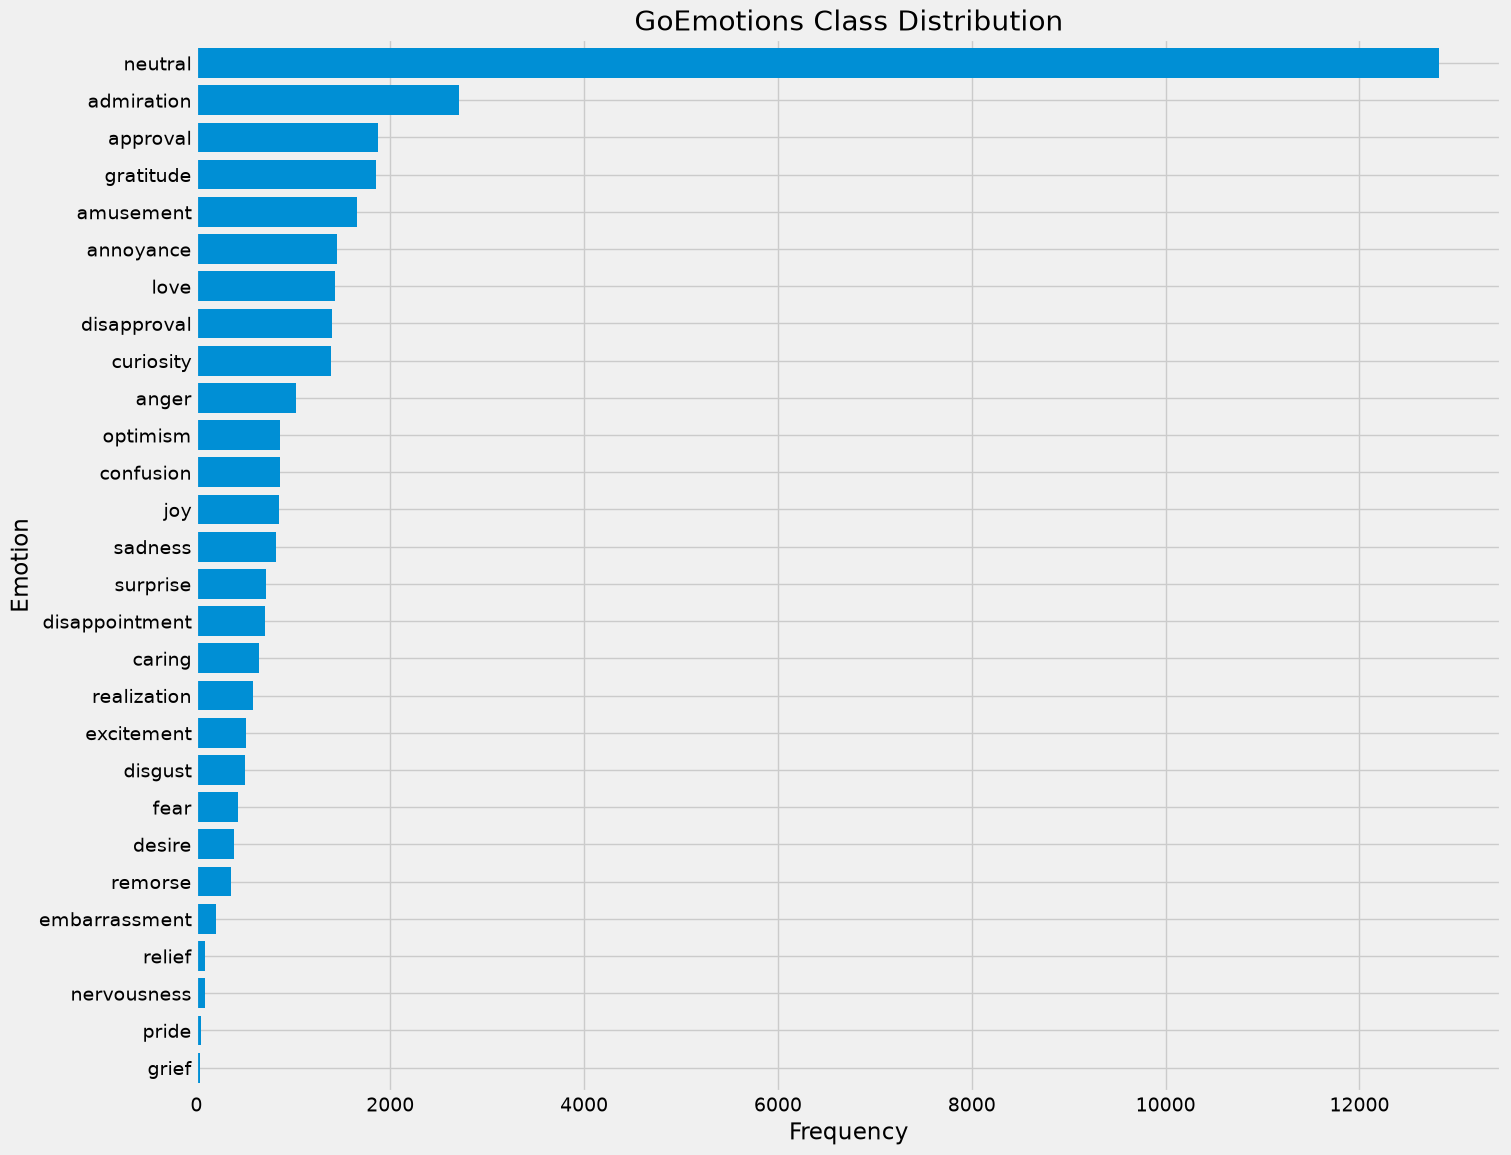

In [24]:
plt.style.use('fivethirtyeight')
class_distribution.sort_values().plot(
    kind="barh",
    figsize=(15, 13), 
    width=0.8
)

plt.xlabel("Frequency")
plt.ylabel("Emotion")
plt.title("GoEmotions Class Distribution")
plt.show()

In [25]:
class_distribution.index

Index(['neutral', 'admiration', 'approval', 'gratitude', 'amusement',
       'annoyance', 'love', 'disapproval', 'curiosity', 'anger', 'optimism',
       'confusion', 'joy', 'sadness', 'surprise', 'disappointment', 'caring',
       'realization', 'excitement', 'disgust', 'fear', 'desire', 'remorse',
       'embarrassment', 'relief', 'nervousness', 'pride', 'grief'],
      dtype='str', name='emotion')

In [26]:
class_distribution.values

array([12823,  2710,  1873,  1857,  1652,  1451,  1427,  1402,  1389,
        1025,   861,   858,   853,   817,   720,   709,   649,   586,
         510,   498,   430,   389,   353,   203,    88,    85,    51,
          39])

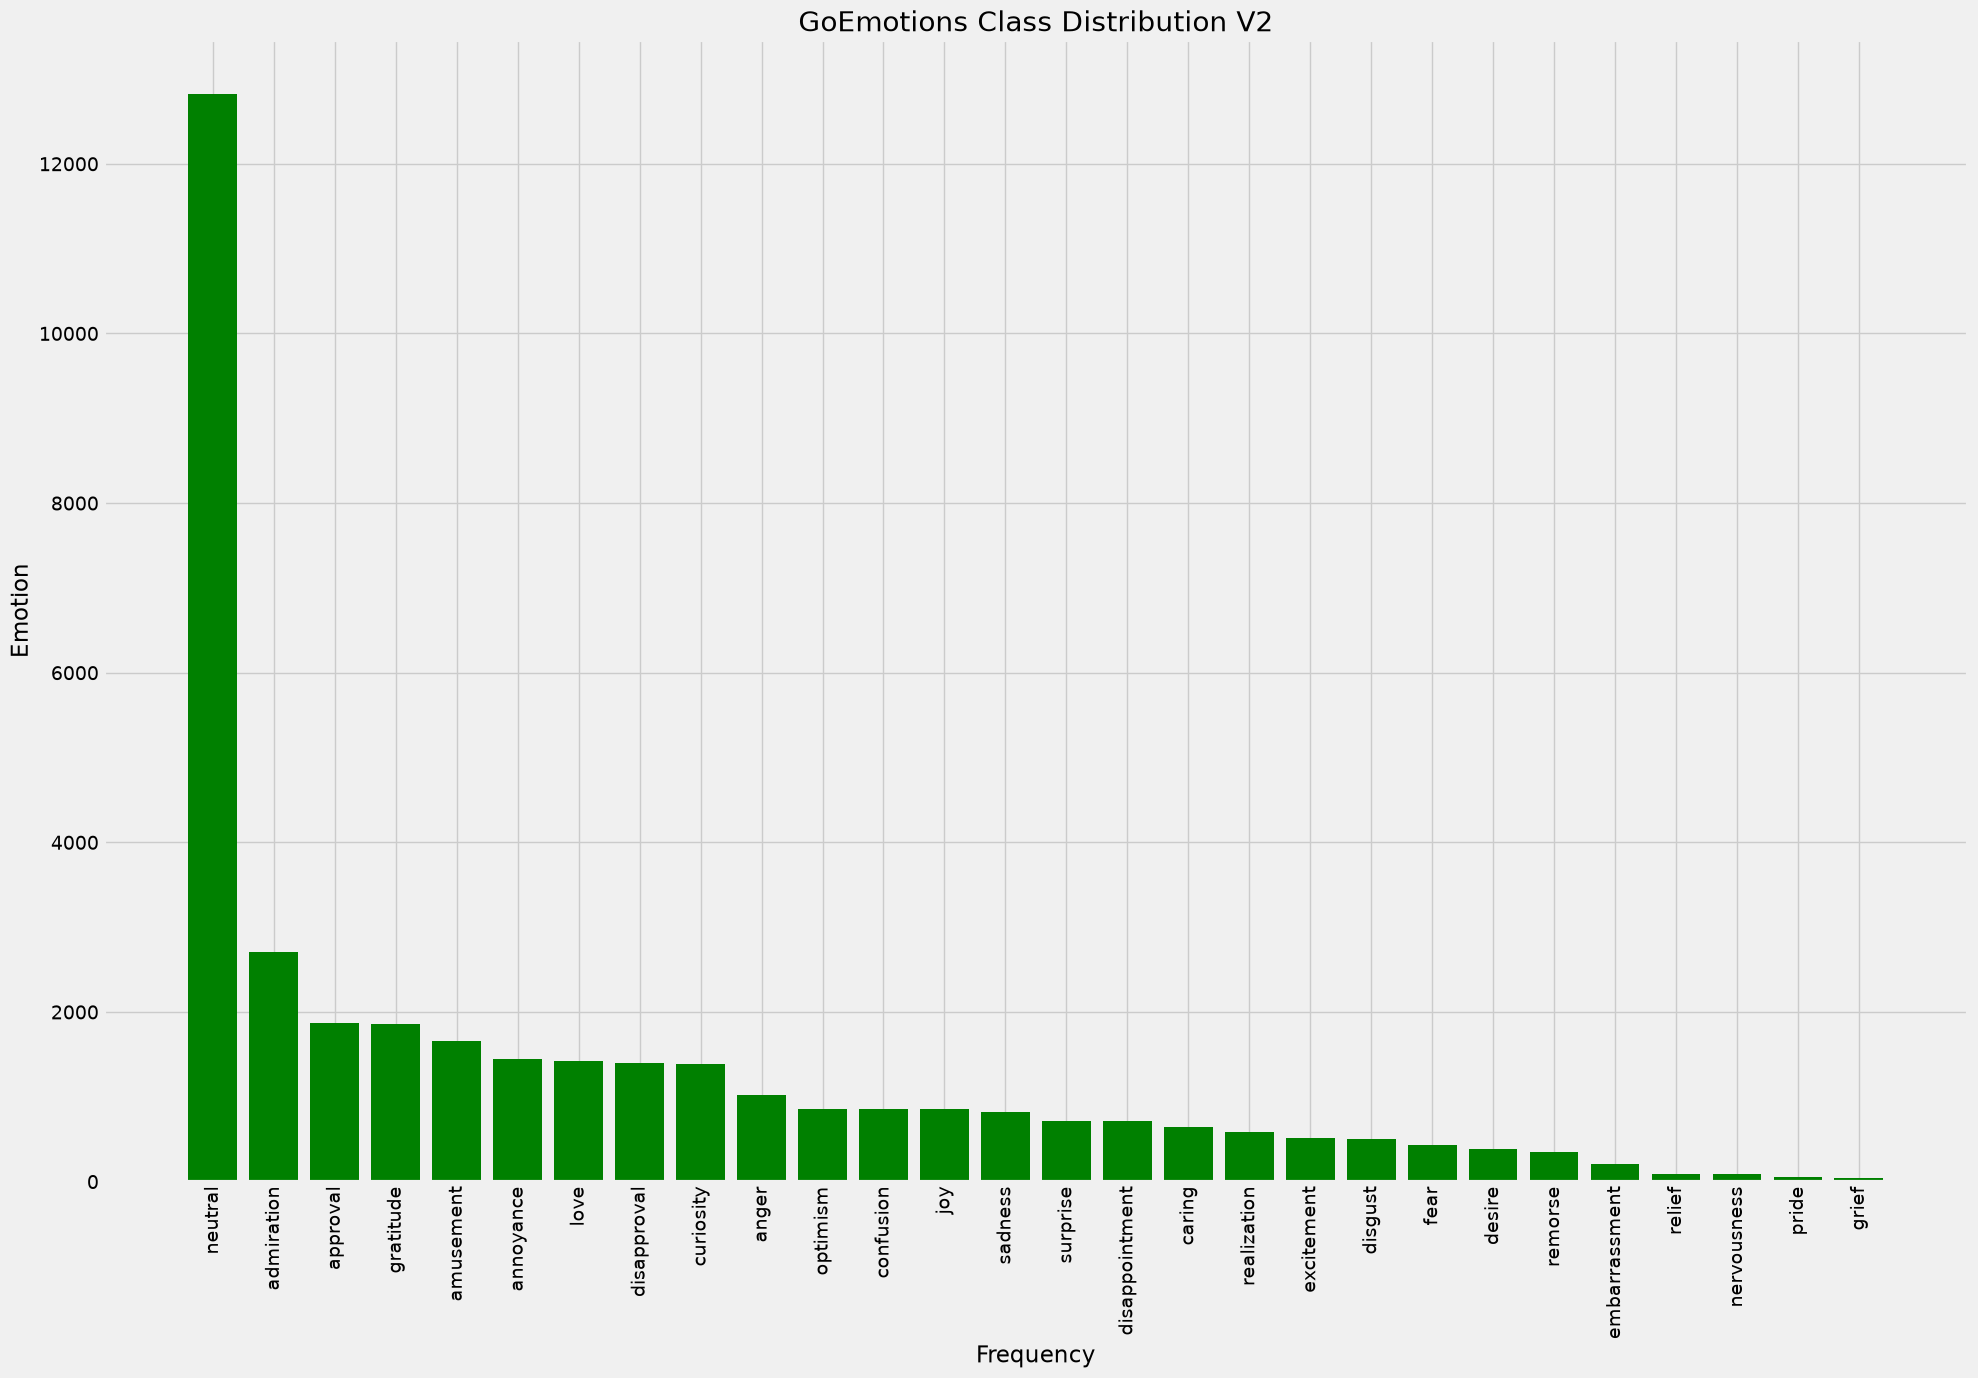

In [27]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(20, 14))
width=0.8

plt.bar(class_distribution.index, class_distribution.values, width=width, color='green')

plt.title("GoEmotions Class Distribution V2")
plt.xlabel("Frequency")
plt.ylabel("Emotion")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [28]:
# Validate there are no missing values.
print(single_label_df[['text', 'emotion']].isnull().sum())

text       0
emotion    0
dtype: int64


## X and Y Training Split

In [29]:
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [30]:
x = single_label_df['text']
x.head()

0    My favourite food is anything I didn't have to...
1    Now if he does off himself, everyone will thin...
2                       WHY THE FUCK IS BAYLESS ISOING
3                          To make her feel threatened
4                               Dirty Southern Wankers
Name: text, dtype: str

In [31]:
y = single_label_df['emotion']
y

0           neutral
1           neutral
2             anger
3              fear
4         annoyance
            ...    
43405          love
43406     confusion
43407     annoyance
43408    excitement
43409           joy
Name: emotion, Length: 36308, dtype: str

In [32]:
print(f'Features: {x.shape}')
print(f'Target: {y.shape}')

Features: (36308,)
Target: (36308,)


### Splitting the data into training and test sets.

* stratify() ensures the proportion of different classes in our target stays approximately the same in both training and testing sets.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_val, y_train, y_val = train_test_split(
  x, 
  y, 
  test_size=0.33, 
  random_state=42, 
  stratify=y
)

In [35]:
print(f'Training Data: {len(X_train)}')
print(f'Validation Data: {len(X_val)}')

Training Data: 24326
Validation Data: 11982


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder


In [37]:
# Convert our emotion labels from text strings into integers.
label_encoder = LabelEncoder()

In [38]:
y_train

459        curiosity
23430      amusement
18493      gratitude
16724    disapproval
17768      gratitude
            ...     
13315          anger
25736        neutral
10516       approval
26792       approval
23429        neutral
Name: emotion, Length: 24326, dtype: str

In [39]:
y_train_ids = label_encoder.fit_transform(y_train)
y_val_ids = label_encoder.transform(y_val)

print(dict(enumerate(label_encoder.classes_)))

{0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness', 20: 'neutral', 21: 'optimism', 22: 'pride', 23: 'realization', 24: 'relief', 25: 'remorse', 26: 'sadness', 27: 'surprise'}


## Why Bert Transformers

* Moving on from BiLSTM(Bidirectional LSTM) to BERT(Bidirectional Encoder Representations from Transformers), so we can use Transformers-based SELF-ATTENTION mechanisms for understanding context.
  - A standard LSTM processes tokens sequentially in only ONE direction.

  - A BiLSTM processes the sequences from both left-to-right and right-to-left.

  - BERT uses self-attention so each token can consider OTHER tpkens in the sequence when creating its representation, instead of processing the sequence one at a time.

  - BERT can create CONTEXTUAL REPRESENTATIONS where the representations of the word can CHANGE depending on the surrounding words


* EX:
  - TF-IDF represents a sentence "I love this game" but doesn't inherently understand the sequence.

  - LSTMs process tokens sequentially, maintaining a hidden state that carries information from previous tokens, providing a mechanism for capturing context and word order.
  
  - BiLSTMs extend this by processing the sequence in BOTH directions, allowing each token's representation to incorporate information from both earlier and later tokens.

  - BERT uses self-attention to directly relate tokens to other tokens in the sequence, allowing it to capture relationships between words regardless of their position.
    - EX:
      - "I went to the bank to deposit money."

      - "I sat beside the river bank."
      
      - BERT can create different contextual representations for "bank" in these two sentences because it considers the surrounding words.

In [40]:
import sys
print(sys.version)

3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]


In [41]:
# %pip install torch torchvision torchaudio
# !pip install transformers datasets accelerate
%pip install transformers datasets accelerate

Note: you may need to restart the kernel to use updated packages.


In [42]:
import transformers
import torch 
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader 
from collections import Counter 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import re

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.17.0
PyTorch: 2.14.0


### Set up BERT

* Load the pretrained BERT tokenizer.

In [44]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

In [45]:
# This downloads the pretrained BERT tokenizer and its vocabulary.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [46]:
text = "I love this game"

tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'love', 'this', 'game']


In [47]:
# BERT converts strings into token IDs
token_ids = tokenizer.encode(text)

print(token_ids)

[101, 1045, 2293, 2023, 2208, 102]


* We no longer have to create our own "vocab" dictioanry or nn.Embedding for BERT.

  - BERT has already learned those repreentations.

### Tokenize X_train and X_Val

* Unlike the LSTM, we don't need text_to_ids(), vocab, or the pad_sequence() function. The BERT tokenizer handles all of that.

In [48]:
X_train

459      I'm curious though, will they upvote it to own...
23430    i'm just making fun of how when moids say they...
18493                                      I will! Thanks!
16724    $11 an hour doesn't leave a lot of room to be ...
17768                                     Oh okay. Thanks.
                               ...                        
13315    Fuck it, maybe the faceless men worship the gr...
25736    I drive semi trucks into denver. Im not there ...
10516    Yeah you're right, I mistyped it. Should have ...
26792    Yes, he's really pushing the Devils to new hei...
23429                                    Resting cash face
Name: text, Length: 24326, dtype: str

In [49]:
sample = X_train[0]
sample

"My favourite food is anything I didn't have to cook myself."

In [50]:
encoded = tokenizer(
  sample, padding="max_length", 
  truncation=True, 
  max_length=128
)

print("Text:", sample)

# The integer IDs representing the tokens.
print("Input IDs:", encoded["input_ids"])

# Tells BERT which positions contain real tokens versus padding.
# BERT explicitly knows which positions are padding through the attention mask.
print("Attention Mask:", encoded["attention_mask"])

Text: My favourite food is anything I didn't have to cook myself.
Input IDs: [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 1005, 1056, 2031, 2000, 5660, 2870, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Tokenize entire datasets.

* For every sentence in X_train, BERT's tokenizer creates:
  - input_ids — the integer token IDs

  - attention_mask — tells BERT which positions are real tokens vs. padding

In [51]:
# Every example becomes exactly 128 positions long.
# truncation=True, means if a sentence is longer than 128 tokens, it gets truncated to 128.
train_encodings = tokenizer(
    list(X_train),
    padding="max_length",
    truncation=True,
    max_length=128
)

val_encodings = tokenizer(
    list(X_val),
    padding="max_length",
    truncation=True,
    max_length=128
)

In [52]:
print("Number of training examples:", len(train_encodings["input_ids"]))
print("Number of validation examples:", len(val_encodings["input_ids"]))

print("Training input shape:", len(train_encodings["input_ids"][0]))
print("Training mask shape:", len(train_encodings["attention_mask"][0]))

Number of training examples: 24326
Number of validation examples: 11982
Training input shape: 128
Training mask shape: 128


### Create PyTorch DataSet

* Creating a PyTorch Dataset that combines these BERT inputs with existing y_train_ids and y_val_ids.

In [53]:
class BERTEmotionDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return {
        "input_ids": torch.tensor(
            self.encodings["input_ids"][idx],
            dtype=torch.long
        ),
        "attention_mask": torch.tensor(
            self.encodings["attention_mask"][idx],
            dtype=torch.long
        ),
        "labels": self.labels[idx]
    }

In [54]:
train_dataset = BERTEmotionDataset(
    train_encodings,
    y_train_ids
)

val_dataset = BERTEmotionDataset(
    val_encodings,
    y_val_ids
)

In [55]:
# Checking one example
sample = train_dataset[0]

print("Input IDs shape:", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Label:", sample["labels"])

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: tensor(7)


### BERT DataLoaders

* BERT is much larger and more computationally expensive than the LSTM/BiLSTM, so we drop the batch_size from 64 to 16. Adjust as necessary.

In [56]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [57]:
batch = next(iter(train_loader))

print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["labels"].shape)

Input IDs shape: torch.Size([16, 128])
Attention mask shape: torch.Size([16, 128])
Labels shape: torch.Size([16])


### Load BERT for Classification

In [58]:
# We may warning saying that some weights were not initialized from the pretrained model. That's expected.
# BERT itself has already been pretrained to learn language representations.
# The new classification layer is being created specifically for our 28 GoEmotions classes.

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=28
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6606.46it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [59]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

* BertForSequenceClassification can calculate the cross-entropy loss for us when we pass labels into the model.  
   - We'll use that when we write the training loop.

### BERT Forward Pass
* We're fiving BERT 3 things:
  - input_ids --> What tokens are in the sentence?

  - attention_mask --> Which positions are real tokens vs padding?

  - labels --> What is the correct emotion?

In [60]:
# BERT Forward Pass
batch = next(iter(train_loader))

outputs = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    labels=batch["labels"]
)

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Logits shape: torch.Size([16, 28])
Loss: 3.385380744934082


In [61]:
# Set up optimzier
# Use smaller LR, BERT already has pretrained weights containing useful language representations. 
# We generally want to make small adjustments to those weights rather than drastically changing them.
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

### Train for a few epochs.

* Maybe start with 3, then maybe 10

In [62]:
import time

In [63]:
tic = time.time()

num_epochs = 3

for epoch in range(num_epochs):
    model.train()

    total_loss = 0

    for batch in train_loader:

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        # BERT calculates CrossEntropyLoss for us
        loss = outputs.loss

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        total_loss += loss.item()

    # Average loss across all batches
    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Training Loss: {avg_loss:.4f}"
    )
    
toc = time.time()

print('time:', round(toc-tic, 2),'s')

Epoch 1/3 - Training Loss: 1.7162
Epoch 2/3 - Training Loss: 1.1887
Epoch 3/3 - Training Loss: 0.9034
time: 8064.19 s


In [66]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [67]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)
macro_f1 = f1_score(all_labels, all_predictions, average="macro")
weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"BERT Accuracy: {accuracy:.4f}")
print(f"BERT Macro F1: {macro_f1:.4f}")
print(f"BERT Weighted F1: {weighted_f1:.4f}")

BERT Accuracy: 0.6029
BERT Macro F1: 0.4736
BERT Weighted F1: 0.5929


In [68]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

    admiration       0.67      0.75      0.71       894
     amusement       0.72      0.84      0.77       545
         anger       0.50      0.48      0.49       338
     annoyance       0.33      0.22      0.26       479
      approval       0.39      0.29      0.34       618
        caring       0.46      0.40      0.43       214
     confusion       0.46      0.43      0.45       283
     curiosity       0.48      0.64      0.55       458
        desire       0.64      0.59      0.62       128
disappointment       0.34      0.24      0.28       234
   disapproval       0.40      0.32      0.36       463
       disgust       0.43      0.51      0.46       164
 embarrassment       0.76      0.46      0.57        67
    excitement       0.34      0.41      0.37       168
          fear       0.56      0.70      0.62       142
     gratitude       0.92      0.89      0.91       613
         grief       0.00      0.00      0.00  

* BERT achieved 60% accuracy using a single-label classifier. This is a substantial improvement over:
  - BiLSTM's 46% accuracy, which may suggest BERT performed better across the emotion classes overall.

* BERT's higher performance is likely due to its pretrained CONTEXTUAL REPRESENTATIONS and SELF-ATTENTION MECHANISM.
  - Unlike the LSTM/BiLSTM models, BERT was pretrained on a large text corpus before being fine-tuned on the GoEMotions dataset.

  - Self-attention enables BERT to consider relationships between tokens across the ENTIRE input when creating textual representations.

  - This helps the model to distinguish words and phrases based on their surrounding context.


* The class imbalance remains an issue.
  - BERT performed well on some classes like gratitude (F1 = 0.91), love (F1 = 0.80), and amusement (F1 = 0.77).

  - However, extremely rare classes such as grief (support = 13, F1 = 0.00) and pride (support = 17, F1 = 0.11) remained difficult.

  - Simply using a more powerful model does not completely solve the class-imbalance problem.

* Increasing the number of training epochs is another possible experiment, but additional training does not necessarily solve class imbalance.
  - The model may continue improving on FREQUENT classes while still struggling with classes that have very few training examples.

  - Possible approaches include class weighting and focal loss
  
* Maybe inverse-frequency class weights, which an give more importance to rare classes during training.
  - Frequent classes receive SMALLER weights because the model already sees many examples of them.

  - Rare classes receive LARGER weights, causing mistakes on those classes to contribute more to the loss.
  
  - This encourages the model to pay more attention to underrepresented emotion classes instead of primarily optimizing for the most frequent classes.
  
  - EX: If "neutral" appears thousands of times but "grief" appears only a few dozen times, a grief classification error would receive a larger loss weight than a neutral classification error.
  
  - This could potentially improve Macro F1 by improving performance across less frequent classes, even if overall accuracy does not increase.


* The current BERT experiment uses a single-label multiclass formulation of GoEmotions, where each example is assigned one emotion class.
  - The original GoEmotions dataset is fundamentally a multi-label emotion classification problem, where a single text can have multiple emotion labels.

* Future experiments can switch to the original multi-label formulation and compare approaches designed specifically for that task.

### Saving the model

* Saving the model since it took roughly 3 hours to train 3 epochs.

In [69]:
import pickle

In [70]:
model.save_pretrained("./bert_goemotions_v1")
tokenizer.save_pretrained("./bert_goemotions_v1")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]


('./bert_goemotions_v1/tokenizer_config.json',
 './bert_goemotions_v1/tokenizer.json')

In [71]:
with open("./bert_goemotions_v1/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [72]:
# Save the label encoders.
with open("./bert_goemotions_v1/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)